In [ ]:
# ============================================================
# INSTALL
# ============================================================
!pip install transformers torch scikit-learn matplotlib seaborn

import json
import re
import os
import zipfile
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torch import nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from collections import defaultdict
from google.colab import files

In [ ]:
# ============================================================
# CONFIG
# ============================================================
MODEL_NAME  = "google/muril-base-cased"
MAX_LEN     = 128
BATCH_SIZE  = 8
EPOCHS      = 8
LR          = 2e-5
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
# ============================================================
# LOAD DATA
# ============================================================
with open("marathi_wsd_dataset_filtered (1).json", "r", encoding="utf-8") as f:
    raw = json.load(f)

# Build helpers from data
sense_gloss = {item["sense_id"]: item["gloss"] for item in raw}

word_senses = defaultdict(set)
for item in raw:
    word_senses[item["target_word"]].add(item["sense_id"])
word_senses = {w: list(s) for w, s in word_senses.items()}

print(f"Total rows loaded: {len(raw)}")
print(f"Total unique senses: {len(sense_gloss)}")
print(f"Total ambiguous words: {len(word_senses)}")

Total rows loaded: 50242
Total unique senses: 50
Total ambiguous words: 16


In [ ]:
# ============================================================
# DATASET
# ============================================================
# We use BinaryWSDDataset for BOTH training and validation
# Each row = (sentence + gloss) pair with label 0 or 1
# label=1 means this gloss is the correct sense for this sentence
# label=0 means this gloss is a wrong sense for this sentence
#
# This is consistent between training and inference
# ============================================================
class BinaryWSDDataset(Dataset):
    def __init__(self, items, tokenizer, max_len):
        self.items     = items
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        item  = self.items[idx]

        # Get gloss for this sense
        gloss = sense_gloss.get(item["sense_id"], item["target_word"])

        # Encode sentence + gloss as a pair
        # This is how the model learns:
        # "Does this sentence match this gloss meaning?"
        enc = self.tokenizer(
            item["sentence"],
            gloss,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "token_type_ids": enc.get(
                "token_type_ids",
                torch.zeros(self.max_len, dtype=torch.long)
            ).squeeze(),
            "label": torch.tensor(item["label"], dtype=torch.long)
        }


In [ ]:
# MODEL
# ============================================================
# Encoder (MuRIL) reads the sentence+gloss pair
# Projector maps CLS vector to a 256-dim sense space
# Classifier gives final binary decision (match or not)
# ============================================================
class WSDModel(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        hidden         = self.encoder.config.hidden_size  # 768 for MuRIL
        self.projector = nn.Sequential(
            nn.Linear(hidden, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256)
        )
        self.classifier = nn.Linear(256, 2)  # binary: correct sense or not

    def encode(self, input_ids, attention_mask, token_type_ids):
        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        cls = out.last_hidden_state[:, 0, :]  # CLS token vector
        return self.projector(cls)             # shape: (B, 256)

    def forward(self, input_ids, attention_mask, token_type_ids):
        emb = self.encode(input_ids, attention_mask, token_type_ids)
        return self.classifier(emb)            # shape: (B, 2) logits


In [ ]:
# ============================================================
# TRAIN / VAL SPLIT
# ============================================================
# Split at sentence level to avoid data leakage
# All rows for a sentence go into the same split
# ============================================================
sentence_groups = defaultdict(list)
for item in raw:
    sentence_groups[item["sentence"]].append(item)

sentences = list(sentence_groups.keys())
train_sents, val_sents = train_test_split(
    sentences, test_size=0.15, random_state=42
)

train_data = [item for s in train_sents for item in sentence_groups[s]]
val_data   = [item for s in val_sents   for item in sentence_groups[s]]

print(f"\nTrain rows: {len(train_data)}")
print(f"Val rows:   {len(val_data)}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ✅ Both train and val use BinaryWSDDataset — consistent
train_ds = BinaryWSDDataset(train_data, tokenizer, MAX_LEN)
val_ds   = BinaryWSDDataset(val_data,   tokenizer, MAX_LEN)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE)

print(f"\nTrain batches: {len(train_dl)}")
print(f"Val batches:   {len(val_dl)}")



Train rows: 42523
Val rows:   7719


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Train batches: 5316
Val batches:   965


In [ ]:
# ============================================================
# LOSS FUNCTION
# ============================================================
# Weighted CrossEntropy handles label imbalance
# In WSD dataset: label=0 rows >> label=1 rows
# Because each sentence has 1 correct sense but N-1 wrong senses
# We upweight label=1 to compensate
# ============================================================
avg_senses = np.mean([len(v) for v in word_senses.values()])
pos_weight = torch.tensor([1.0, float(avg_senses - 1)]).to(DEVICE)
ce_loss_fn = nn.CrossEntropyLoss(weight=pos_weight)

print(f"\nAverage senses per word: {avg_senses:.1f}")
print(f"Loss weight for label=1: {float(avg_senses - 1):.1f}")



Average senses per word: 3.1
Loss weight for label=1: 2.1


In [ ]:
from tqdm import tqdm

# ============================================================
# TRAINING LOOP
# ============================================================
model     = WSDModel(MODEL_NAME).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

total_steps = len(train_dl) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=max(1, total_steps // 10),
    num_training_steps=total_steps
)

best_f1        = 0.0
train_loss_log = []
val_f1_log     = []

print("\n" + "=" * 60)
print("TRAINING STARTED")
print("=" * 60)

for epoch in range(EPOCHS):

    # ── Train ──────────────────────────────────────────────
    model.train()
    total_loss = 0.0

    for batch in tqdm(train_dl, desc=f"Epoch {epoch+1} Training"):
        optimizer.zero_grad()

        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )

        loss = ce_loss_fn(logits, batch["label"].to(DEVICE))
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_dl)
    train_loss_log.append(avg_loss)

    # ── Validate ───────────────────────────────────────────
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(val_dl, desc=f"Epoch {epoch+1} Validation"):
            logits = model(
                batch["input_ids"].to(DEVICE),
                batch["attention_mask"].to(DEVICE),
                batch["token_type_ids"].to(DEVICE)
            )

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch["label"].cpu().numpy())   # ✅ FIXED

    f1 = f1_score(all_labels, all_preds, average="macro")
    val_f1_log.append(f1)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Macro-F1: {f1:.4f}")

    # Save best model
    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_muril_wsd.pt")
        print(f"  ✅ Saved best model (F1={f1:.4f})")

print(f"\nBest Macro-F1: {best_f1:.4f}")

# ── Final Evaluation on Best Model ──────────────────────────
model.load_state_dict(torch.load("best_muril_wsd.pt"))
model.to(DEVICE)
model.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(val_dl, desc="Final Evaluation"):
        logits = model(
            batch["input_ids"].to(DEVICE),
            batch["attention_mask"].to(DEVICE),
            batch["token_type_ids"].to(DEVICE)
        )

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["label"].cpu().numpy())

print("\nFinal Classification Report:")
print(classification_report(all_labels, all_preds, target_names=["Wrong", "Correct"]))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google/muril-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



TRAINING STARTED


Epoch 1 Validation: 100%|██████████| 965/965 [00:55<00:00, 17.53it/s]


Epoch 1/8 | Loss: 0.5258 | Macro-F1: 0.7978
  ✅ Saved best model (F1=0.7978)


...

Epoch 7/8 | Loss: 0.2481 | Macro-F1: 0.8569


Epoch 8 Validation: 100%|██████████| 965/965 [00:54<00:00, 17.78it/s]


Epoch 8/8 | Loss: 0.2365 | Macro-F1: 0.8592

Best Macro-F1: 0.8602


Final Evaluation: 100%|██████████| 965/965 [00:54<00:00, 17.70it/s]


Final Classification Report:
              precision    recall  f1-score   support

       Wrong       0.89      0.94      0.91      5206
     Correct       0.86      0.76      0.81      2513

    accuracy                           0.88      7719
   macro avg       0.88      0.85      0.86      7719
weighted avg       0.88      0.88      0.88      7719



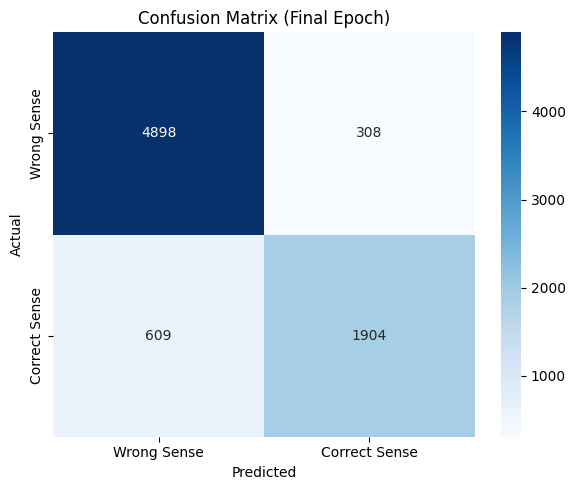

Confusion matrix saved


In [ ]:

# ============================================================
# CONFUSION MATRIX
# ============================================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["Wrong Sense", "Correct Sense"],
    yticklabels=["Wrong Sense", "Correct Sense"]
)
plt.title("Confusion Matrix (Final Epoch)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved")


In [ ]:

# ============================================================
# LOAD BEST MODEL FOR INFERENCE
# ============================================================
print("\n" + "=" * 60)
print("Loading best checkpoint for inference")
print("=" * 60)

# ✅ Fixed — checkpoint is just state_dict(), load directly
best_ckpt = torch.load("best_muril_wsd.pt", map_location=DEVICE)
model.load_state_dict(best_ckpt)
model.eval()
print("Best model loaded successfully")



Loading best checkpoint for inference
Best model loaded successfully


In [ ]:

# ============================================================
# INFERENCE FUNCTION
# ============================================================
# How inference works:
# 1. Detect which ambiguous word is in the sentence
# 2. For each candidate sense of that word:
#    Encode (sentence + gloss) pair
#    Get probability that this is the correct sense
# 3. Pick sense with highest probability
#
# ✅ This matches exactly how the model was trained
# ============================================================
def predict_auto(sentence):
    model.eval()

    # Step 1 — detect ambiguous words in sentence
    tokens = re.findall(r'[\u0900-\u097F]+', sentence)
    found_words = list({
        w for tok in tokens
        for w in word_senses
        if tok.startswith(w)
    })

    if not found_words:
        print(f"❌ No known ambiguous word found in sentence")
        print(f"   Known words: {list(word_senses.keys())}")
        return

    print(f"\n📝 Sentence: {sentence}")
    print(f"🔍 Detected ambiguous words: {found_words}")

    for target_word in found_words:
        candidates = word_senses.get(target_word, [])
        scores = {}

        for sid in candidates:
            gloss = sense_gloss.get(sid, "")

            # ✅ Encode as (sentence, gloss) pair — same as training
            enc = tokenizer(
                sentence,
                gloss,
                max_length=MAX_LEN,
                padding="max_length",
                truncation=True,
                return_tensors="pt"
            )

            with torch.no_grad():
                logits = model(
                    enc["input_ids"].to(DEVICE),
                    enc["attention_mask"].to(DEVICE),
                    enc.get(
                        "token_type_ids",
                        torch.zeros(MAX_LEN, dtype=torch.long).unsqueeze(0)
                    ).to(DEVICE)
                )

            # Probability of label=1 (correct sense)
            prob = torch.softmax(logits, dim=1)[0][1].item()
            scores[sid] = prob

        best_sid = max(scores, key=scores.get)

        print(f"\n{'─'*55}")
        print(f"🎯 Word: '{target_word}'")
        print(f"{'─'*55}")
        for sid, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
            marker = "✅" if sid == best_sid else "  "
            gloss  = sense_gloss.get(sid, "")[:55]
            print(f"  {marker} Sense {sid} ({score:.4f}) — {gloss}")
        print(f"\n  🏆 Predicted sense : {best_sid}")
        print(f"     Gloss          : {sense_gloss.get(best_sid, '')}")
        print(f"{'─'*55}")



In [ ]:

# ============================================================
# TEST INFERENCE WITH SAMPLE SENTENCES
# ============================================================
print("\n" + "=" * 60)
print("INFERENCE TEST")
print("=" * 60)

test_sentences = [
    "काल रात्री उशिरापर्यंत काम केल्यामुळे माझा डोळाच लागला नाही.",
    "शेतकरी नेहमी उसाचा डोळा बघूनच त्याची लागवड करतात.",
    "पोलिसांचा त्या संशयित व्यक्तीवर अनेक दिवसांपासून बारीक डोळा होता.",
]

for sent in test_sentences:
    predict_auto(sent)
    print()



INFERENCE TEST

📝 Sentence: काल रात्री उशिरापर्यंत काम केल्यामुळे माझा डोळाच लागला नाही.
🔍 Detected ambiguous words: ['डोळा']

───────────────────────────────────────────────────────
🎯 Word: 'डोळा'
───────────────────────────────────────────────────────
  ✅ Sense 103 (0.9795) — अचानक झोप येणे किंवा थोडी डुलकी लागणे (Sleep / Nap)
     Sense 104 (0.1269) — एखाद्या व्यक्तीवर किंवा गोष्टीवर बारीक लक्ष ठेवणे, पाळत
     Sense 102 (0.0201) — बटाटा, ऊस किंवा इतर झाडांवर येणारा छोटा कोंब, ज्यातून न
     Sense 105 (0.0125) — धान्य दळण्याच्या जुन्या जात्याला मध्यभागी असलेले भोक, ज
     Sense 101 (0.0112) — आपल्या शरीराचा तो अवयव ज्याच्या मदतीने आपण बघतो (Eye / 

  🏆 Predicted sense : 103
     Gloss          : अचानक झोप येणे किंवा थोडी डुलकी लागणे (Sleep / Nap)
───────────────────────────────────────────────────────


📝 Sentence: शेतकरी नेहमी उसाचा डोळा बघूनच त्याची लागवड करतात.
🔍 Detected ambiguous words: ['डोळा']

───────────────────────────────────────────────────────
🎯 Word: 'डोळा'
──────────

In [ ]:

# ============================================================
# EXPORT DEPLOYMENT PACKAGE
# ============================================================
EXPORT_DIR = "marathi_wsd_deployment"
os.makedirs(EXPORT_DIR, exist_ok=True)

# 1. Tokenizer
tokenizer.save_pretrained(f"{EXPORT_DIR}/tokenizer")
print("✅ Tokenizer saved")

# 2. Model weights
torch.save(model.state_dict(), f"{EXPORT_DIR}/model_weights.pt")
print("✅ Model weights saved")

# 3. Encoder config
model.encoder.config.save_pretrained(f"{EXPORT_DIR}/encoder_config")
print("✅ Encoder config saved")

# 4. Metadata — everything needed to run inference later
metadata = {
    "model_name":     MODEL_NAME,
    "max_len":        MAX_LEN,
    "sense_gloss":    sense_gloss,
    "word_to_senses": dict(word_senses),
}
with open(f"{EXPORT_DIR}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print("✅ Metadata saved")

# 5. Training plots
for plot_file in ["training_curves.png", "confusion_matrix.png"]:
    if os.path.exists(plot_file):
        os.rename(plot_file, f"{EXPORT_DIR}/{plot_file}")
print("✅ Training plots saved")

# 6. Zip everything
zip_path = "marathi_wsd_deployment.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, file_list in os.walk(EXPORT_DIR):
        for file in file_list:
            filepath = os.path.join(root, file)
            zf.write(filepath, os.path.relpath(filepath))

print(f"\n✅ Zipped: {zip_path}")
files.download(zip_path)

✅ Tokenizer saved
✅ Model weights saved
✅ Encoder config saved
✅ Metadata saved
✅ Training plots saved

✅ Zipped: marathi_wsd_deployment.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>